✅ Semua file berhasil dimuat.
Lokasi dataset: /Users/azzizabdulghofur/Documents/Telkom University/Kompetisi/Lomba/Lomba Machine Learning Quest - Intelectra 2025/dataset

ANALISIS: Data Anggota (member_data.csv)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46401 entries, 0 to 46400
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   MemberID        46401 non-null  object
 1   JoinDate        46401 non-null  object
 2   DateOfBirth     1477 non-null   object
 3   City            46401 non-null  object
 4   NoOfChild       46401 non-null  int64 
 5   EldestKidDOB    46401 non-null  object
 6   YoungestKidDOB  46401 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.5+ MB

Statistik Deskriptif:
                                MemberID    JoinDate DateOfBirth    City  \
count                              46401       46401        1477   46401   
unique                             46401        

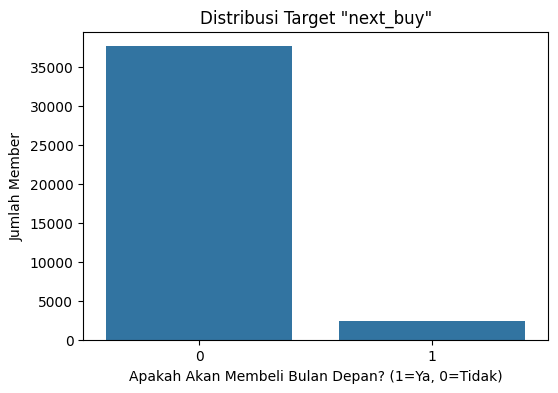


ANALISIS: Data Produk (product_data.csv)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   productID        27 non-null     int64 
 1   ProductName      27 non-null     object
 2   ProductCategory  27 non-null     object
 3   ProductLevel     27 non-null     object
dtypes: int64(1), object(3)
memory usage: 996.0+ bytes

Jumlah Nilai Hilang:
productID          0
ProductName        0
ProductCategory    0
ProductLevel       0
dtype: int64

Contoh Data:
   productID        ProductName ProductCategory ProductLevel
0          1                A 3               A     Original
1          2                B 4               B     Original
2          3                A G               A      Premium
3          4                B G               B      Premium
4          9  A G FOR HOME KIOS               A      Premium

ANALISIS: Data Prog

In [14]:
# ==============================================================================
# TAHAP 1: IMPORT LIBRARY DAN MEMUAT DATA
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Mengatur path ke folder dataset dari folder notebooks
# Tanda '..' berarti 'naik satu level direktori'
base_path = '../dataset/'

# Memuat semua dataset yang relevan
try:
    member_df = pd.read_csv(os.path.join(base_path, 'member_data.csv'))
    train_trans_df = pd.read_csv(os.path.join(base_path, 'train_transaction_data.csv'))
    train_label_df = pd.read_csv(os.path.join(base_path, 'train_label_data.csv'))
    product_df = pd.read_csv(os.path.join(base_path, 'product_data.csv'))
    prodgram_df = pd.read_csv(os.path.join(base_path, 'prodgram_data.csv'))
    
    print("✅ Semua file berhasil dimuat.")
    print("Lokasi dataset:", os.path.abspath(base_path))
except FileNotFoundError as e:
    print(f"❌ Gagal memuat file: {e}")
    print("Pastikan file CSV Anda berada di dalam folder 'dataset' dan notebook ini berada di dalam folder 'notebooks'.")

# ==============================================================================
# TAHAP 2: ANALISIS SETIAP TABEL SECARA INDIVIDUAL
# ==============================================================================

print("\n" + "="*50)
print("ANALISIS: Data Anggota (member_data.csv)")
print("="*50)
print("\nInfo Data:")
member_df.info()
print("\nStatistik Deskriptif:")
print(member_df.describe(include='all'))
print("\nJumlah Nilai Hilang:")
print(member_df.isnull().sum())
print("\nContoh Data:")
print(member_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Transaksi Latih (train_transaction_data.csv)")
print("="*50)
print("\nInfo Data:")
train_trans_df.info()
print("\nStatistik Deskriptif:")
print(train_trans_df.describe(include='all'))
print("\nJumlah Nilai Hilang:")
print(train_trans_df.isnull().sum())
print("\nContoh Data:")
print(train_trans_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Label Latih (train_label_data.csv)")
print("="*50)
print("\nInfo Data:")
train_label_df.info()
print("\nJumlah Nilai Hilang:")
print(train_label_df.isnull().sum())
print("\nDistribusi Target (next_buy):")
print(train_label_df['next_buy'].value_counts(normalize=True))
print("\nContoh Data:")
print(train_label_df.head())

# Visualisasi distribusi target
plt.figure(figsize=(6, 4))
sns.countplot(x='next_buy', data=train_label_df)
plt.title('Distribusi Target "next_buy"')
plt.xlabel('Apakah Akan Membeli Bulan Depan? (1=Ya, 0=Tidak)')
plt.ylabel('Jumlah Member')
plt.show()


print("\n" + "="*50)
print("ANALISIS: Data Produk (product_data.csv)")
print("="*50)
print("\nInfo Data:")
product_df.info()
print("\nJumlah Nilai Hilang:")
print(product_df.isnull().sum())
print("\nContoh Data:")
print(product_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Program Produk (prodgram_data.csv)")
print("="*50)
print("\nInfo Data:")
prodgram_df.info()
print("\nJumlah Nilai Hilang:")
print(prodgram_df.isnull().sum())
print("\nContoh Data:")
print(prodgram_df.head())


# ==============================================================================
# TAHAP 3: PENGGABUNGAN DATA AWAL (FIRST MERGE)
# ==============================================================================
print("\n" + "="*50)
print("PENGGABUNGAN DATA AWAL")
print("="*50)

# Menggabungkan data transaksi latih dengan labelnya
train_merged_df = pd.merge(train_trans_df, train_label_df, on='MemberID', how='left')

print("Info data setelah digabung dengan label:")
train_merged_df.info()

print("\nJumlah nilai hilang di kolom 'next_buy' setelah merge:")
print(f"{train_merged_df['next_buy'].isnull().sum()} (Seharusnya 0 jika semua MemberID di data transaksi ada di data label)")

print("\nContoh data gabungan:")
print(train_merged_df.head())

In [15]:
# ==============================================================================
# TAHAP 4: PEMBERSIHAN DAN PERSIAPAN DATA (KODE YANG DIPERBAIKI)
# ==============================================================================
print("Memulai proses pembersihan data...")

# Salin dataframe agar data asli tidak berubah
member_clean = member_df.copy()
train_trans_clean = train_trans_df.copy()
prodgram_clean = prodgram_df.copy()

# --- 1. Mengubah Tipe Data Kolom Tanggal ---
print("\n1. Mengubah tipe data kolom tanggal menjadi datetime...")
date_cols_member = ['JoinDate', 'EldestKidDOB', 'YoungestKidDOB']
# Kita tidak memasukkan 'DateOfBirth' karena akan dihapus
for col in date_cols_member:
    member_clean[col] = pd.to_datetime(member_clean[col], errors='coerce')

train_trans_clean['TransactionDatetime'] = pd.to_datetime(train_trans_clean['TransactionDatetime'])

print("Tipe data member_clean setelah diubah:")
print(member_clean.dtypes)
print("\nTipe data train_trans_clean setelah diubah:")
print(train_trans_clean.dtypes)


# --- 2. Menangani Nilai Hilang (Missing Values) ---
print("\n2. Menangani nilai hilang...")

# 2a. DateOfBirth pada member_data kita drop karena >95% hilang
member_clean = member_clean.drop(columns=['DateOfBirth'])
print("- Kolom 'DateOfBirth' telah dihapus.")

# 2b. PricePerUnit pada data transaksi
# Strategi: Isi dengan harga referensi dari prodgram_data
train_trans_clean = pd.merge(
    train_trans_clean,
    prodgram_clean[['prodgramID', 'Price']],
    left_on='FK_PROD_GRAM_ID',
    right_on='prodgramID',
    how='left'
)

# --- INILAH BAGIAN YANG DIPERBAIKI ---
# Mengisi PricePerUnit yang kosong dengan Price dari prodgram
train_trans_clean['PricePerUnit'] = train_trans_clean['PricePerUnit'].fillna(train_trans_clean['Price'])

# Hapus kolom bantu yang sudah tidak diperlukan
train_trans_clean = train_trans_clean.drop(columns=['prodgramID', 'Price'])
print(f"- Nilai hilang di 'PricePerUnit' setelah diisi dari harga referensi: {train_trans_clean['PricePerUnit'].isnull().sum()}")

# Jika masih ada yg kosong, isi dengan median
if train_trans_clean['PricePerUnit'].isnull().sum() > 0:
    median_price = train_trans_clean['PricePerUnit'].median()
    # --- INILAH BAGIAN KEDUA YANG DIPERBAIKI ---
    train_trans_clean['PricePerUnit'] = train_trans_clean['PricePerUnit'].fillna(median_price)
    print(f"- Mengisi sisa nilai hilang 'PricePerUnit' dengan median ({median_price}).")


# --- 3. Menggabungkan Semua Data Menjadi Satu DataFrame Final ---
print("\n3. Menggabungkan semua tabel menjadi satu DataFrame...")

# Gabungkan data transaksi yang sudah bersih dengan data member
df_train_full = pd.merge(train_trans_clean, member_clean, on='MemberID', how='left')

# Gabungkan dengan data produk
product_df_renamed = product_df.rename(columns={'productID': 'FK_PRODUCT_ID'})
df_train_full = pd.merge(df_train_full, product_df_renamed, on='FK_PRODUCT_ID', how='left')

# Gabungkan dengan data prodgram (untuk info gramasi & poin)
prodgram_df_renamed = prodgram_df.rename(columns={'prodgramID': 'FK_PROD_GRAM_ID'})
df_train_full = pd.merge(df_train_full, prodgram_df_renamed, on='FK_PROD_GRAM_ID', how='left')


print("\n--- DATA BERSIH DAN LENGKAP SIAP UNTUK FEATURE ENGINEERING ---")
print("Info Data Gabungan Final:")
df_train_full.info()

print("\nMemeriksa kembali nilai hilang pada data gabungan:")
# Tampilkan hanya kolom yang masih memiliki nilai hilang
missing_final = df_train_full.isnull().sum()
print(missing_final[missing_final > 0])

Memulai proses pembersihan data...

1. Mengubah tipe data kolom tanggal menjadi datetime...
Tipe data member_clean setelah diubah:
MemberID                  object
JoinDate          datetime64[ns]
DateOfBirth               object
City                      object
NoOfChild                  int64
EldestKidDOB      datetime64[ns]
YoungestKidDOB    datetime64[ns]
dtype: object

Tipe data train_trans_clean setelah diubah:
TransactionID                       object
MemberID                            object
Source                              object
FK_PRODUCT_ID                        int64
FK_PROD_GRAM_ID                      int64
Qty                                  int64
PricePerUnit                       float64
TransactionDatetime    datetime64[ns, UTC]
dtype: object

2. Menangani nilai hilang...
- Kolom 'DateOfBirth' telah dihapus.
- Nilai hilang di 'PricePerUnit' setelah diisi dari harga referensi: 0

3. Menggabungkan semua tabel menjadi satu DataFrame...

--- DATA BERSIH DAN LENGKA

In [16]:
# ==============================================================================
# TAHAP 5: REKAYASA FITUR (FEATURE ENGINEERING) - KODE DIPERBAIKI
# ==============================================================================
print("Memulai proses rekayasa fitur...")

# --- 1. Membuat Fitur Dasar per Transaksi ---
df_train_full['TotalPrice'] = df_train_full['Qty'] * df_train_full['PricePerUnit']
df_train_full['DiscountApplied'] = (df_train_full['PricePerUnit'] < df_train_full['Price']).astype(int)

# Tentukan tanggal referensi (snapshot_date). Ini masih timezone-aware (UTC).
snapshot_date = df_train_full['TransactionDatetime'].max() + pd.Timedelta(days=1)
print(f"Tanggal referensi untuk recency: {snapshot_date.date()}")


# --- 2. Agregasi Data per MemberID ---
features_df = df_train_full.groupby('MemberID').agg(
    # Recency: Keduanya (snapshot_date dan date.max()) adalah aware, jadi ini aman.
    recency=('TransactionDatetime', lambda date: (snapshot_date - date.max()).days),
    frequency_trans=('TransactionID', 'count'),
    frequency_days=('TransactionDatetime', lambda date: date.dt.date.nunique()),
    monetary_total=('TotalPrice', 'sum'),
    monetary_mean=('TotalPrice', 'mean'),
    monetary_max=('TotalPrice', 'max'),
    product_unique_count=('FK_PRODUCT_ID', 'nunique'),
    category_unique_count=('ProductCategory', 'nunique'),
    total_points=('Point', 'sum'),
    total_discounted_trans=('DiscountApplied', 'sum')
).reset_index()


# --- 3. Membuat Fitur Tambahan ---
features_df['discount_ratio'] = features_df['total_discounted_trans'] / features_df['frequency_trans']
features_df['avg_qty_per_trans'] = df_train_full.groupby('MemberID')['Qty'].sum().reset_index(drop=True) / features_df['frequency_trans']


# --- 4. Menggabungkan dengan Fitur Statis dari Data Member ---
member_static_features = member_clean.drop_duplicates(subset=['MemberID']).copy()

# ### INILAH BAGIAN YANG DIPERBAIKI ###
# Untuk menghitung tenure, kita buat snapshot_date menjadi timezone-naive agar cocok dengan JoinDate.
snapshot_date_naive = snapshot_date.tz_localize(None)
member_static_features['tenure_days'] = (snapshot_date_naive - member_static_features['JoinDate']).dt.days

# Gabungkan fitur agregat dengan fitur statis member
features_df = pd.merge(features_df, member_static_features[['MemberID', 'City', 'NoOfChild', 'tenure_days']], on='MemberID', how='left')


# --- 5. Menggabungkan dengan Label Target (next_buy) ---
final_train_df = pd.merge(features_df, train_label_df, on='MemberID', how='left')


# --- 6. Menangani Nilai Hilang (jika ada) setelah merge ---
# Ada kemungkinan tenure_days menjadi NaN jika JoinDate-nya kosong
if final_train_df['tenure_days'].isnull().any():
    final_train_df['tenure_days'].fillna(final_train_df['tenure_days'].median(), inplace=True)


print("\n--- PROSES REKAYASA FITUR SELESAI ---")
print("Dimensi data latih final:", final_train_df.shape)
print("\nInfo Data Latih Final:")
final_train_df.info(verbose=False) # Ringkas
print("\nContoh Data Latih Final (siap untuk model):")
print(final_train_df.head())

Memulai proses rekayasa fitur...
Tanggal referensi untuk recency: 2021-07-01

--- PROSES REKAYASA FITUR SELESAI ---
Dimensi data latih final: (40020, 17)

Info Data Latih Final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40020 entries, 0 to 40019
Columns: 17 entries, MemberID to next_buy
dtypes: float64(5), int64(10), object(2)
memory usage: 5.2+ MB

Contoh Data Latih Final (siap untuk model):
                           MemberID  recency  frequency_trans  frequency_days  \
0  00010c8a563eb5555709c8ae3120ba2e      161                1               1   
1  000184877b42ade87143636847f305a8      254                1               1   
2  0003a82569e3202cfecc55d987da0f70        3               11              11   
3  00045f29692019c0fa274e5330c5dbaf      116                2               2   
4  0004aec4786c2b071360a0967b39f4f5      132               20              20   

   monetary_total  monetary_mean  monetary_max  product_unique_count  \
0         83000.0   83000.000000     

Memulai proses persiapan dan pelatihan model...

Fitur (X) dan Target (y) sudah dipisahkan.
Dimensi Fitur (X): (40020, 15)

Data dibagi menjadi 32016 baris untuk latih dan 8004 baris untuk validasi.

Melatih model LightGBM...
Nilai scale_pos_weight untuk kelas positif: 15.42
[LightGBM] [Info] Number of positive: 1950, number of negative: 30066
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2142
[LightGBM] [Info] Number of data points in the train set: 32016, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.060907 -> initscore=-2.735566
[LightGBM] [Info] Start training from score -2.735566

Mengevaluasi performa model pada data validasi...

🏆 Balanced Accuracy Score: 0.8682

Laporan Klasifikasi:
                precision    recall  f1-score   support

Ti

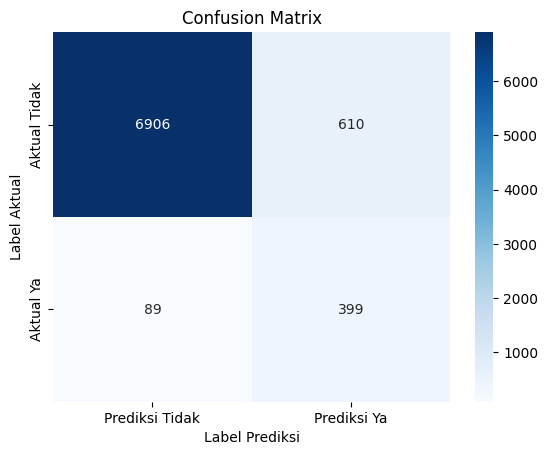

In [17]:
# ==============================================================================
# TAHAP 6: PELATIHAN DAN EVALUASI MODEL
# ==============================================================================
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Memulai proses persiapan dan pelatihan model...")

# --- 1. Persiapan Data untuk Model ---

# Pisahkan fitur (X) dan target (y)
# Kita akan drop kolom ID dan target dari fitur
X = final_train_df.drop(columns=['MemberID', 'next_buy'])
y = final_train_df['next_buy']

# Mengubah kolom 'City' menjadi tipe data 'category' agar bisa di-handle langsung oleh LightGBM
# Ini adalah cara yang efisien untuk menangani fitur kategori dengan banyak nilai unik
X['City'] = X['City'].astype('category')

print("\nFitur (X) dan Target (y) sudah dipisahkan.")
print("Dimensi Fitur (X):", X.shape)


# --- 2. Pembagian Data Latih dan Validasi ---
# Kita bagi data menjadi 80% untuk latih dan 20% untuk validasi
# 'stratify=y' penting agar proporsi kelas 0 dan 1 sama di data latih dan validasi
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, # 'random_state' agar hasil pembagian data selalu sama
    stratify=y
)

print(f"\nData dibagi menjadi {len(X_train)} baris untuk latih dan {len(X_val)} baris untuk validasi.")


# --- 3. Pelatihan Model LightGBM ---
print("\nMelatih model LightGBM...")

# Menghitung 'scale_pos_weight' untuk menangani data tidak seimbang
# Rumus: jumlah sampel negatif / jumlah sampel positif
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Nilai scale_pos_weight untuk kelas positif: {scale_pos_weight:.2f}")

# Inisialisasi model LightGBM Classifier
lgbm = lgb.LGBMClassifier(
    objective='binary',
    metric='balanced_accuracy',
    scale_pos_weight=scale_pos_weight, # Parameter kunci untuk data imbalanced!
    random_state=42
)

# Melatih model
# Kita perlu memberitahu model mana kolom kategori
lgbm.fit(X_train, y_train, categorical_feature=['City'])


# --- 4. Evaluasi Model pada Data Validasi ---
print("\nMengevaluasi performa model pada data validasi...")

# Membuat prediksi pada data validasi
y_pred = lgbm.predict(X_val)

# Menghitung Balanced Accuracy Score
balanced_acc = balanced_accuracy_score(y_val, y_pred)
print(f"\n================================================")
print(f"🏆 Balanced Accuracy Score: {balanced_acc:.4f}")
print(f"================================================")

# Menampilkan laporan klasifikasi yang lebih detail
print("\nLaporan Klasifikasi:")
print(classification_report(y_val, y_pred, target_names=['Tidak Beli (0)', 'Beli (1)']))

# Menampilkan Confusion Matrix untuk melihat detail kesalahan
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Prediksi Tidak', 'Prediksi Ya'], yticklabels=['Aktual Tidak', 'Aktual Ya'])
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.title('Confusion Matrix')
plt.show()

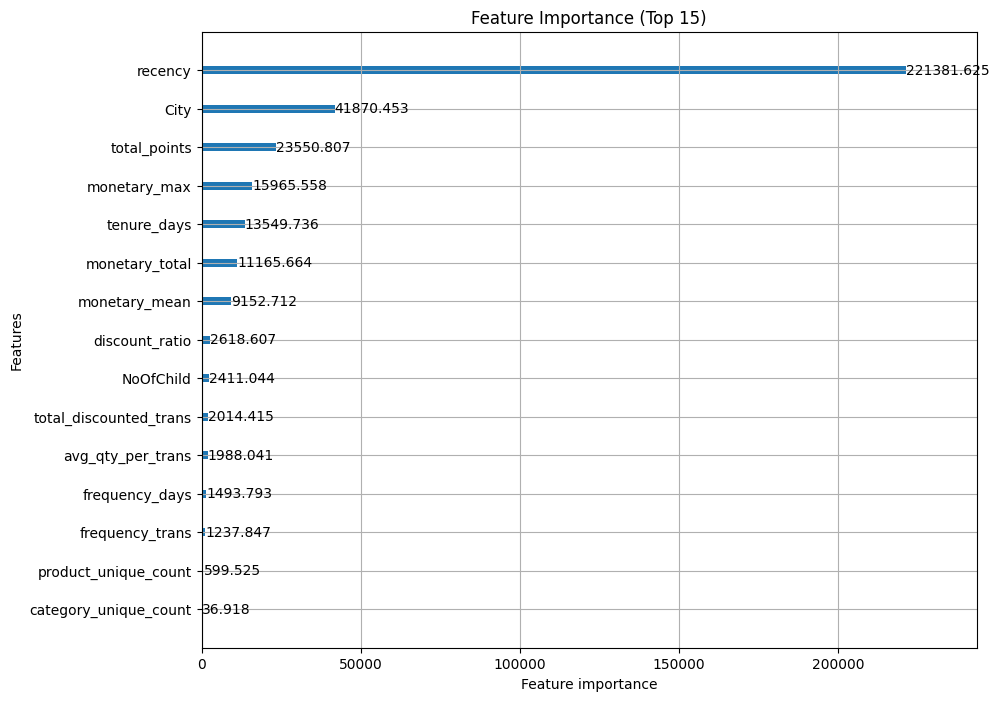

In [18]:
# ==============================================================================
# TAHAP 7: ANALISIS FEATURE IMPORTANCE
# ==============================================================================
# Membuat plot feature importance
lgb.plot_importance(lgbm, max_num_features=15, figsize=(10, 8), importance_type='gain')
plt.title('Feature Importance (Top 15)')
plt.show()

In [19]:
# ==============================================================================
# TAHAP 8: FINAL MODEL TRAINING & SUBMISSION (KODE DIPERBAIKI)
# ==============================================================================
print("--- Memulai Proses Pembuatan Submission ---")

# --- 1. Final Model Training (menggunakan 100% data latih) ---
print("\n1. Melatih model final pada seluruh data latih...")

X_full_train = final_train_df.drop(columns=['MemberID', 'next_buy'])
y_full_train = final_train_df['next_buy']
X_full_train['City'] = X_full_train['City'].astype('category')

final_lgbm = lgb.LGBMClassifier(
    objective='binary',
    metric='balanced_accuracy',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
final_lgbm.fit(X_full_train, y_full_train)
print("Model final berhasil dilatih.")

# --- 2. Memuat dan Memproses Data Tes ---
print("\n2. Memuat dan memproses data tes...")
test_trans_df = pd.read_csv('../dataset/test_transaction_data.csv')

# ### INILAH BAGIAN YANG DIPERBAIKI ###
# Mengambil sample submission dari folder yang benar
sample_submission_df = pd.read_csv('../submissions/sample_submission.csv')

# Menjalankan SEMUA langkah cleaning & feature engineering yang SAMA pada data tes
test_trans_clean = test_trans_df.copy()
test_trans_clean['TransactionDatetime'] = pd.to_datetime(test_trans_clean['TransactionDatetime'])
test_trans_clean = pd.merge(test_trans_clean, prodgram_clean[['prodgramID', 'Price']], left_on='FK_PROD_GRAM_ID', right_on='prodgramID', how='left')
test_trans_clean['PricePerUnit'] = test_trans_clean['PricePerUnit'].fillna(test_trans_clean['Price'])
test_trans_clean = test_trans_clean.drop(columns=['prodgramID', 'Price'])
if test_trans_clean['PricePerUnit'].isnull().sum() > 0:
    median_price_train = X_full_train['PricePerUnit'].median()
    test_trans_clean['PricePerUnit'] = test_trans_clean['PricePerUnit'].fillna(median_price_train)

df_test_full = pd.merge(test_trans_clean, member_clean, on='MemberID', how='left')
product_df_renamed = product_df.rename(columns={'productID': 'FK_PRODUCT_ID'})
df_test_full = pd.merge(df_test_full, product_df_renamed, on='FK_PRODUCT_ID', how='left')
prodgram_df_renamed = prodgram_df.rename(columns={'prodgramID': 'FK_PROD_GRAM_ID'})
df_test_full = pd.merge(df_test_full, prodgram_df_renamed, on='FK_PROD_GRAM_ID', how='left')

df_test_full['TotalPrice'] = df_test_full['Qty'] * df_test_full['PricePerUnit']
df_test_full['DiscountApplied'] = (df_test_full['PricePerUnit'] < df_test_full['Price']).astype(int)

test_features_df = df_test_full.groupby('MemberID').agg(
    recency=('TransactionDatetime', lambda date: (snapshot_date - date.max()).days),
    frequency_trans=('TransactionID', 'count'),
    frequency_days=('TransactionDatetime', lambda date: date.dt.date.nunique()),
    monetary_total=('TotalPrice', 'sum'),
    monetary_mean=('TotalPrice', 'mean'),
    monetary_max=('TotalPrice', 'max'),
    product_unique_count=('FK_PRODUCT_ID', 'nunique'),
    category_unique_count=('ProductCategory', 'nunique'),
    total_points=('Point', 'sum'),
    total_discounted_trans=('DiscountApplied', 'sum')
).reset_index()

test_features_df['discount_ratio'] = test_features_df['total_discounted_trans'] / test_features_df['frequency_trans']
test_features_df['avg_qty_per_trans'] = df_test_full.groupby('MemberID')['Qty'].sum().reset_index(drop=True) / test_features_df['frequency_trans']

member_static_features_test = member_clean.drop_duplicates(subset=['MemberID']).copy()
snapshot_date_naive = snapshot_date.tz_localize(None)
member_static_features_test['tenure_days'] = (snapshot_date_naive - member_static_features_test['JoinDate']).dt.days
test_features_df = pd.merge(test_features_df, member_static_features_test[['MemberID', 'City', 'NoOfChild', 'tenure_days']], on='MemberID', how='left')

final_test_df = pd.merge(sample_submission_df[['MemberID']], test_features_df, on='MemberID', how='left')

for col in X_full_train.columns:
    if final_test_df[col].isnull().any():
        if final_test_df[col].dtype.name == 'category':
             # Untuk kategori, isi dengan modus (nilai paling sering muncul) dari data latih
            final_test_df[col] = final_test_df[col].cat.add_categories(X_full_train[col].mode()[0])
            final_test_df[col].fillna(X_full_train[col].mode()[0], inplace=True)
        else:
             # Untuk numerik, isi dengan median dari data latih
            final_test_df[col].fillna(X_full_train[col].median(), inplace=True)

final_test_df['City'] = final_test_df['City'].astype('category')
print("Data tes berhasil diproses.")

# --- 3. Membuat Prediksi dan Menyimpan File ---
print("\n3. Membuat prediksi pada data tes...")
X_test_final = final_test_df[X_full_train.columns]
test_predictions = final_lgbm.predict(X_test_final)
submission_df = pd.DataFrame({'MemberID': final_test_df['MemberID'], 'next_buy': test_predictions})

# Menyimpan ke folder yang benar
submission_df.to_csv('../submissions/submission_final.csv', index=False)

print("\n🎉 File 'submission_final.csv' telah berhasil dibuat di dalam folder 'submissions' dan siap untuk diunggah!")
print(submission_df.head())

--- Memulai Proses Pembuatan Submission ---

1. Melatih model final pada seluruh data latih...
[LightGBM] [Info] Number of positive: 2438, number of negative: 37582
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000794 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2176
[LightGBM] [Info] Number of data points in the train set: 40020, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.060920 -> initscore=-2.735347
[LightGBM] [Info] Start training from score -2.735347
Model final berhasil dilatih.

2. Memuat dan memproses data tes...
Data tes berhasil diproses.

3. Membuat prediksi pada data tes...

🎉 File 'submission_final.csv' telah berhasil dibuat di dalam folder 'submissions' dan siap untuk diunggah!
                           MemberID  next_buy
0  c2a630e3d0dc77dac0f63424a9ae1438         0
1  3ecf7484c084